# Exploratory Data Analysis (EDA) of the Titanic Dataset

**Author:** Sara Meziani

**Platform:** Microsoft Azure Machine Learning

**Project:** Titanic Fare Prediction using AutoML Regression

**Objective:** This notebook presents an exploratory data analysis (EDA) of the Titanic dataset. The purpose of this analysis is to understand the dataset structure, identify missing values, explore the distributions of variables, and investigate relationships between features before developing a regression model to predict passenger ticket fares.

In [2]:
# Import the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots inside the notebook
%matplotlib inline

In [3]:
# Load the Titanic dataset

df = pd.read_csv("train.csv")

In [4]:
# Display the first five rows

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Dataset Loading

The Titanic dataset was successfully imported into the Jupyter Notebook using the Pandas library. The first five observations were displayed to verify that the dataset was correctly loaded and to obtain an initial overview of its structure.

In [5]:
# Display the dimensions of the dataset
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 891
Number of columns: 12


## Dataset Dimensions

The Titanic dataset contains **891 observations** and **12 variables**. Each row represents one passenger, while each column corresponds to a specific passenger attribute such as age, sex, ticket fare, or survival status.

In [6]:
# Display information about the dataset
df.info()

# Display the data types
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

## 3. Dataset Structure

The `info()` function was used to examine the overall structure of the Titanic dataset, including the number of observations, data types, and the presence of missing values.

### Dataset Overview

The dataset consists of **891 passenger records** described by **12 variables**. These variables include both numerical and categorical features that provide information about passenger demographics, travel details, and ticket information.

The variables are distributed as follows:

- **5 integer variables (`int64`)**
- **2 floating-point variables (`float64`)**
- **5 categorical variables (`object`)**

### Variable Types

The numerical variables are:

- PassengerId
- Survived
- Pclass
- Age
- SibSp
- Parch
- Fare

The categorical variables are:

- Name
- Sex
- Ticket
- Cabin
- Embarked

This combination of numerical and categorical variables makes the dataset suitable for both statistical analysis and machine learning applications.

### Missing Values

The dataset contains missing values in three variables:

| Variable | Non-null values | Missing values |
|----------|----------------:|---------------:|
| Age | 714 | 177 |
| Cabin | 204 | 687 |
| Embarked | 889 | 2 |

The **Cabin** variable contains a substantial proportion of missing values (approximately **77%**), making it a candidate for either removal or advanced imputation techniques. The **Age** variable has approximately **20%** missing observations and will require appropriate preprocessing before model development. The **Embarked** variable contains only two missing values, which can be handled easily during the data cleaning stage.

### Conclusion

The initial inspection shows that the Titanic dataset is generally well structured and contains a rich combination of numerical and categorical variables. However, missing values—particularly in the **Cabin** and **Age** variables—must be addressed during the data preprocessing phase to ensure the development of a reliable machine learning model.


In [7]:
# Summary statistics for numerical variables
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 4. Descriptive Statistics

The `describe()` function was used to generate summary statistics for the numerical variables in the Titanic dataset. This analysis provides valuable insights into the central tendency, variability, and distribution of the data, helping identify potential issues such as missing values and outliers.

### Overall Observations

The dataset contains 891 observations for most numerical variables. However, the **Age** variable includes only 714 valid observations, confirming the presence of **177 missing values**, which will need to be addressed during the data preprocessing stage.

### Analysis of the Target Variable: Fare

The target variable, **Fare**, represents the ticket price paid by each passenger.

The descriptive statistics reveal the following:

- Mean: **32.20**
- Median: **14.45**
- Standard deviation: **49.69**
- Minimum: **0.00**
- Maximum: **512.33**

The mean is considerably higher than the median, indicating that the distribution of ticket fares is **positively skewed**. Furthermore, the maximum fare is substantially larger than the third quartile (31.00), suggesting the presence of **extreme values (outliers)** corresponding to exceptionally expensive tickets. The relatively high standard deviation also reflects a large variability in ticket prices.

### Analysis of Passenger Age

The average passenger age is **29.70 years**, with ages ranging from **0.42** to **80 years**. The proximity between the mean (29.70) and the median (28.00) suggests a more balanced distribution compared with the Fare variable. Nevertheless, the missing values observed in this variable should be considered during data preprocessing.

### Passenger Class

The median value of **Pclass** is **3**, indicating that the majority of passengers travelled in **third class**. This suggests that the dataset is dominated by passengers from the lowest travel class.

### Survival Status

The **Survived** variable is binary, where 0 represents passengers who did not survive and 1 represents those who survived. Its mean value of **0.384** indicates that approximately **38.4%** of the passengers survived the disaster, while **61.6%** did not.

### Family-Related Variables

The variables **SibSp** (number of siblings/spouses aboard) and **Parch** (number of parents/children aboard) both have a median value of **0**, indicating that most passengers travelled without close family members.

### Conclusion

The descriptive analysis highlights several important characteristics of the dataset. The **Fare** variable exhibits a highly right-skewed distribution with significant variability and potential outliers, making it an interesting target for regression modeling. Additionally, the presence of missing values, particularly in the **Age** variable, emphasizes the importance of appropriate data preprocessing before developing machine learning models.


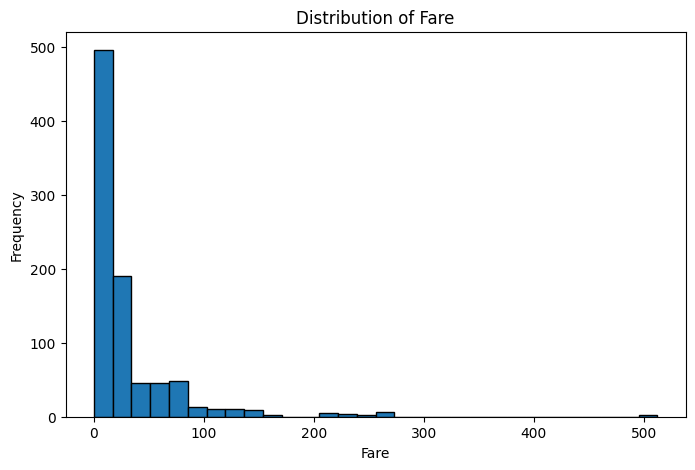

In [8]:
# Histogram of the Fare variable

plt.figure(figsize=(8,5))

plt.hist(df['Fare'], bins=30, edgecolor='black')

plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Frequency')

plt.show()

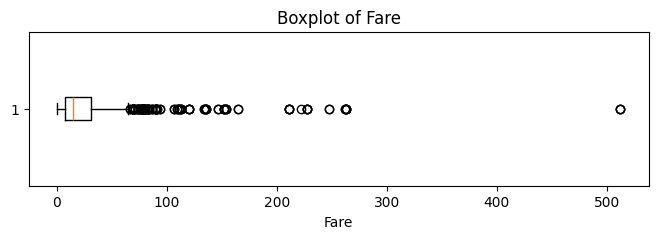

In [9]:
# Boxplot of the Fare variable

plt.figure(figsize=(8,2))

plt.boxplot(df['Fare'], vert=False)

plt.title('Boxplot of Fare')
plt.xlabel('Fare')

plt.show()

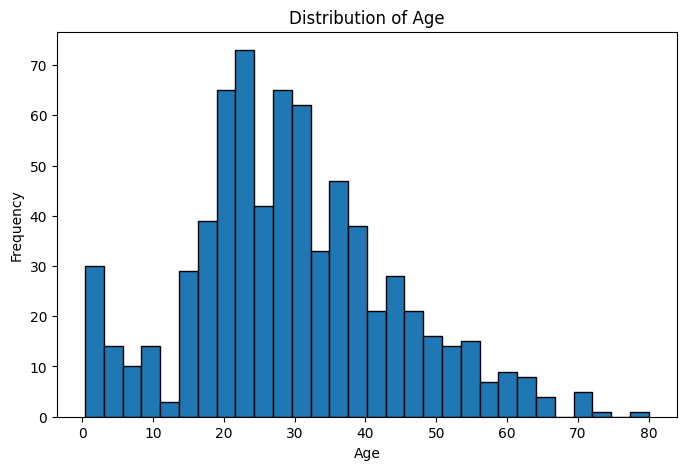

In [10]:
# Histogram of Age

plt.figure(figsize=(8,5))

plt.hist(df['Age'].dropna(), bins=30, edgecolor='black')

plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

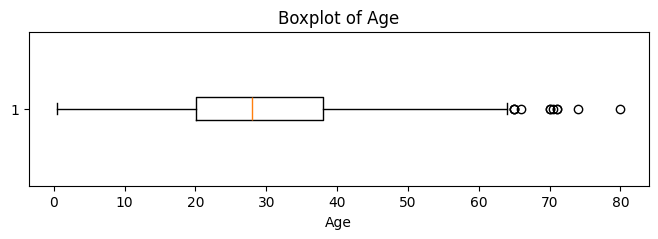

In [11]:
# Boxplot of Age

plt.figure(figsize=(8,2))

plt.boxplot(df['Age'].dropna(), vert=False)

plt.title('Boxplot of Age')
plt.xlabel('Age')

plt.show()

## 5. Univariate Analysis

This section explores the distribution of the two main numerical variables, **Fare** and **Age**, using histograms and boxplots. These visualizations provide valuable insights into the distribution, variability, and presence of potential outliers.

### 5.1 Distribution of the Fare Variable

The histogram of the **Fare** variable shows that ticket prices are **highly positively skewed**. Most passengers paid relatively low fares, while only a small number of passengers paid exceptionally high ticket prices.

This observation is consistent with the descriptive statistics, where the mean (**32.20**) is substantially higher than the median (**14.45**). Such a difference indicates that a few large values pull the average upward.

The corresponding boxplot confirms the presence of **numerous outliers**, particularly for fares greater than approximately 60. A few passengers paid extremely expensive fares, with the highest ticket reaching approximately **512.33**.

These results indicate that the Fare variable does not follow a normal distribution and exhibits considerable variability. Consequently, regression models may be influenced by these extreme observations, making appropriate preprocessing or robust modeling techniques important.

---

### 5.2 Distribution of the Age Variable

The histogram of the **Age** variable shows that most passengers were between **20 and 40 years old**, with the highest concentration around the late twenties.

Compared with the Fare variable, the Age distribution appears much more balanced, although it exhibits a slight positive skew due to a relatively small number of older passengers.

The boxplot identifies a limited number of outliers corresponding to elderly passengers, particularly those older than 65 years. However, these observations are realistic and represent actual passenger ages rather than data entry errors.

Overall, the Age variable displays a more regular distribution than Fare and contains relatively few extreme values.

---

### Conclusion

The graphical analysis confirms the findings obtained from the descriptive statistics.

- The **Fare** variable is strongly right-skewed and contains several extreme values, indicating high variability in ticket prices.
- The **Age** variable has a more balanced distribution, with only a few naturally occurring outliers.
- These observations provide valuable insight into the characteristics of the dataset and highlight important considerations for subsequent data preprocessing and machine learning model development.


In [12]:
# Average fare by passenger class

fare_by_class = df.groupby('Pclass')['Fare'].mean()

print(fare_by_class)

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64


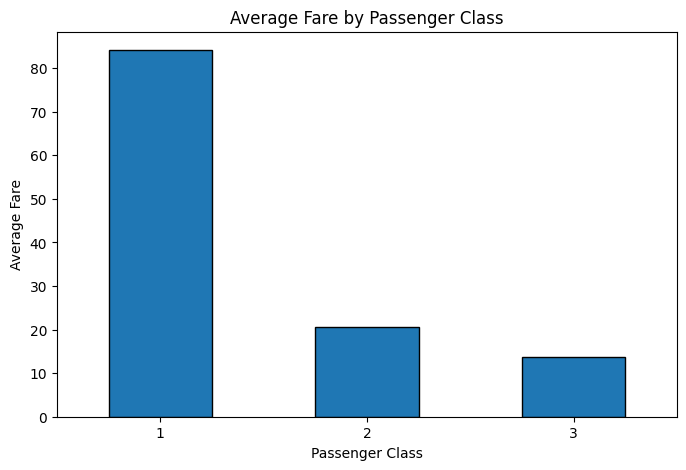

In [13]:
plt.figure(figsize=(8,5))

fare_by_class.plot(kind='bar', edgecolor='black')

plt.title('Average Fare by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Average Fare')

plt.xticks(rotation=0)

plt.show()

In [14]:
# Average fare by gender

fare_by_sex = df.groupby('Sex')['Fare'].mean()

print(fare_by_sex)

Sex
female    44.479818
male      25.523893
Name: Fare, dtype: float64


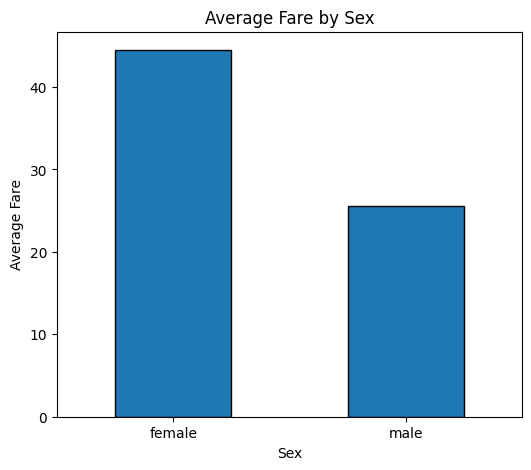

In [15]:
plt.figure(figsize=(6,5))

fare_by_sex.plot(kind='bar', edgecolor='black')

plt.title('Average Fare by Sex')
plt.xlabel('Sex')
plt.ylabel('Average Fare')

plt.xticks(rotation=0)

plt.show()

In [16]:
# Average fare by port of embarkation

fare_by_embarked = df.groupby('Embarked')['Fare'].mean()

print(fare_by_embarked)

Embarked
C    59.954144
Q    13.276030
S    27.079812
Name: Fare, dtype: float64


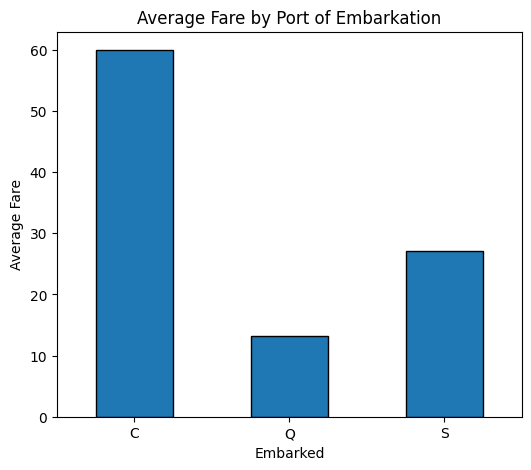

In [17]:
plt.figure(figsize=(6,5))

fare_by_embarked.plot(kind='bar', edgecolor='black')

plt.title('Average Fare by Port of Embarkation')
plt.xlabel('Embarked')
plt.ylabel('Average Fare')

plt.xticks(rotation=0)

plt.show()

In [18]:
# Average fare by survival status

fare_by_survival = df.groupby('Survived')['Fare'].mean()

print(fare_by_survival)

Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64


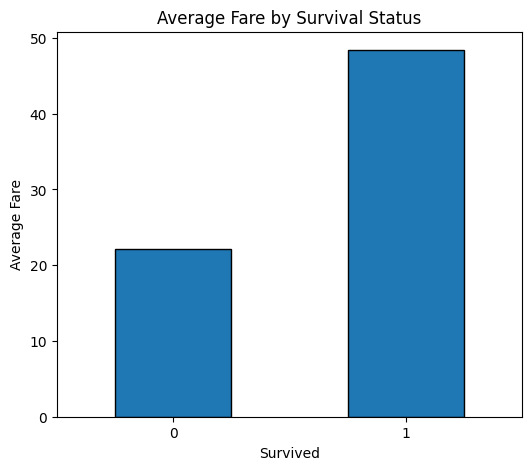

In [19]:
plt.figure(figsize=(6,5))

fare_by_survival.plot(kind='bar', edgecolor='black')

plt.title('Average Fare by Survival Status')
plt.xlabel('Survived')
plt.ylabel('Average Fare')

plt.xticks(rotation=0)

plt.show()

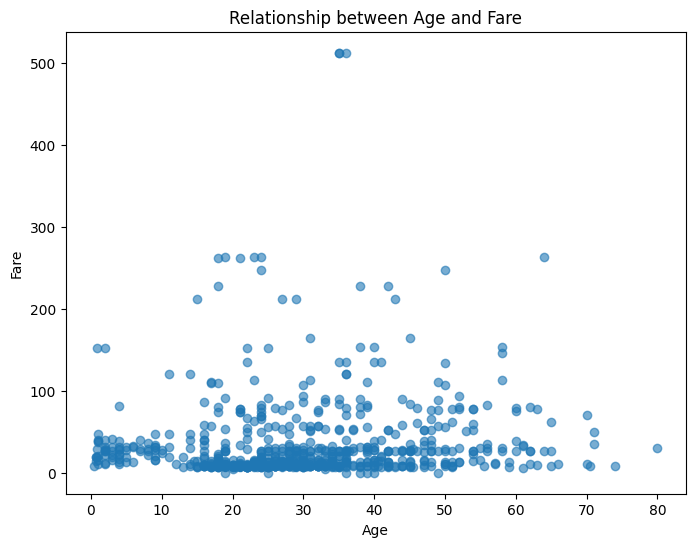

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(df['Age'], df['Fare'], alpha=0.6)

plt.title('Relationship between Age and Fare')
plt.xlabel('Age')
plt.ylabel('Fare')

plt.show()

## 6. Bivariate Analysis

Bivariate analysis was performed to investigate the relationships between the target variable (**Fare**) and several explanatory variables. Understanding these relationships helps identify the factors that may influence ticket prices and provides valuable insights for regression modeling.

### 6.1 Fare by Passenger Class

The average ticket fare varies considerably across passenger classes.

- **First Class:** approximately **84.15**
- **Second Class:** approximately **20.66**
- **Third Class:** approximately **13.68**

The results clearly indicate that passengers travelling in **First Class** paid substantially higher fares than those in Second and Third Class. This finding suggests that **Passenger Class (Pclass)** is one of the strongest predictors of ticket price.

---

### 6.2 Fare by Sex

The average ticket fare also differs between male and female passengers.

| Sex | Average Fare |
|------|-------------:|
| Female | **44.48** |
| Male | **25.52** |

Female passengers paid considerably higher fares on average than male passengers. This difference may be explained by the fact that a larger proportion of female passengers travelled in higher passenger classes.

---

### 6.3 Fare by Port of Embarkation

The average fare varies according to the port where passengers boarded the Titanic.

| Port | Average Fare |
|------|-------------:|
| Cherbourg (C) | **59.95** |
| Queenstown (Q) | **13.28** |
| Southampton (S) | **27.08** |

Passengers embarking from **Cherbourg (C)** paid the highest average fares, whereas passengers from **Queenstown (Q)** paid the lowest. This suggests that the port of embarkation is associated with ticket prices and may indirectly reflect differences in passenger class or travel conditions.

---

### 6.4 Fare by Survival Status

The relationship between ticket fare and passenger survival reveals a noticeable difference.

- **Did not survive (0):** average fare ≈ **22.12**
- **Survived (1):** average fare ≈ **48.40**

Passengers who survived paid considerably higher fares on average than those who did not survive. This observation is consistent with the historical fact that first-class passengers, who generally paid higher ticket prices, had better access to lifeboats and therefore experienced higher survival rates.

---

### 6.5 Relationship Between Age and Fare

The scatter plot illustrates the relationship between passenger age and ticket fare.

The figure shows **no strong linear relationship** between these two variables. Passengers of different ages paid a wide range of ticket prices, indicating that age alone is not a strong predictor of fare.

However, the scatter plot reveals several passengers who paid exceptionally high fares, confirming the presence of **outliers** previously identified during the univariate analysis. Most observations are concentrated below **100** monetary units, while only a few passengers paid more than **200**, with the highest fare exceeding **500**.

---

### Conclusion

The bivariate analysis identifies several variables that are strongly associated with ticket prices.

- **Passenger Class (Pclass)** has the strongest relationship with Fare, with first-class passengers paying significantly higher ticket prices.
- **Sex** also shows differences in average fare, with female passengers paying more on average than male passengers.
- **Port of Embarkation** appears to influence ticket prices, with passengers embarking from Cherbourg paying the highest fares.
- **Survival status** is associated with Fare, reflecting the historical relationship between higher-class passengers and higher survival rates.
- In contrast, **Age** exhibits little direct relationship with Fare, suggesting that it may contribute less to predicting ticket prices than the other variables.

These findings provide valuable insights into the factors influencing ticket prices and will guide feature selection during the machine learning modeling stage.


In [21]:
# Compute the correlation matrix for numerical variables

correlation_matrix = df.corr(numeric_only=True)

print(correlation_matrix)

             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.036847 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.077221 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.369226  0.083081  0.018443   
Age             0.036847 -0.077221 -0.369226  1.000000 -0.308247 -0.189119   
SibSp          -0.057527 -0.035322  0.083081 -0.308247  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.189119  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096067  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096067  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


In [22]:
# Correlation with Fare

fare_correlation = correlation_matrix['Fare'].sort_values(ascending=False)

print(fare_correlation)

Fare           1.000000
Survived       0.257307
Parch          0.216225
SibSp          0.159651
Age            0.096067
PassengerId    0.012658
Pclass        -0.549500
Name: Fare, dtype: float64


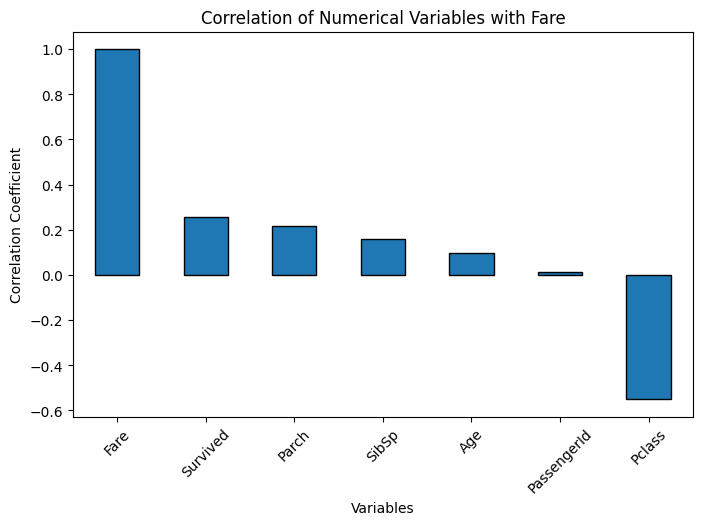

In [23]:
plt.figure(figsize=(8,5))

fare_correlation.plot(kind='bar', edgecolor='black')

plt.title('Correlation of Numerical Variables with Fare')
plt.xlabel('Variables')
plt.ylabel('Correlation Coefficient')

plt.xticks(rotation=45)

plt.show()

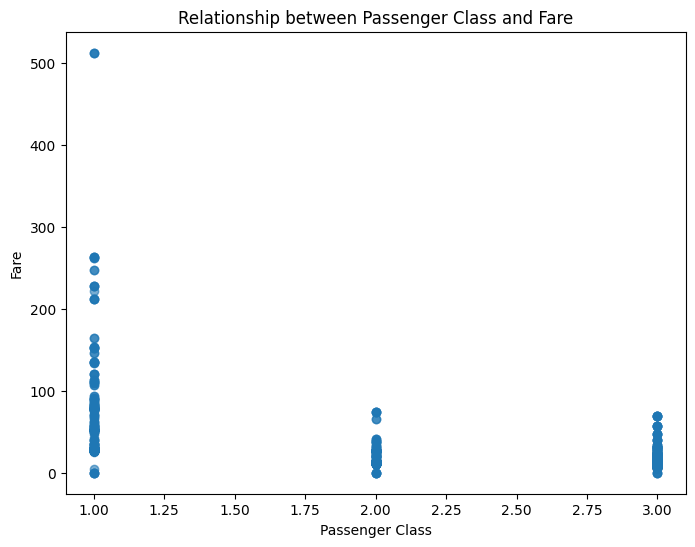

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(df['Pclass'], df['Fare'], alpha=0.6)

plt.title('Relationship between Passenger Class and Fare')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')

plt.show()

## 7. Correlation Analysis

Correlation analysis was performed to measure the strength and direction of the linear relationships between the numerical variables in the Titanic dataset. The Pearson correlation coefficient was used, with values ranging from **-1** (strong negative correlation) to **+1** (strong positive correlation).

### Correlation with the Target Variable (Fare)

The correlation coefficients between **Fare** and the numerical variables are summarized below.

| Variable | Correlation with Fare |
|----------|----------------------:|
| Survived | **0.257** |
| Parch | **0.216** |
| SibSp | **0.160** |
| Age | **0.096** |
| PassengerId | **0.013** |
| Pclass | **-0.550** |

The results indicate that **Passenger Class (Pclass)** has the strongest relationship with the target variable, exhibiting a **moderately strong negative correlation (-0.550)**. Since passenger classes are encoded numerically (1 = First Class, 2 = Second Class, 3 = Third Class), the negative coefficient indicates that ticket fares decrease as the passenger class number increases. In other words, first-class passengers generally paid the highest fares, while third-class passengers paid the lowest.

The **Survived** variable shows a weak positive correlation (**0.257**) with Fare, suggesting that passengers who paid higher ticket prices were more likely to survive. This finding is consistent with historical records, as many first-class passengers had better access to lifeboats.

The variables **Parch** and **SibSp** exhibit weak positive correlations with Fare, indicating that passengers travelling with family members tended to pay slightly higher fares.

The **Age** variable has only a very weak positive correlation (**0.096**), suggesting that passenger age has little influence on ticket price.

Finally, **PassengerId** shows virtually no correlation with Fare, which is expected since it is simply a unique identifier assigned to each passenger.

---

### Relationship Between Passenger Class and Fare

The scatter plot illustrates the relationship between **Passenger Class** and **Fare**.

The visualization clearly confirms the correlation analysis. Passengers travelling in **First Class** paid significantly higher ticket prices and displayed the widest range of fares, including the highest observed value in the dataset (approximately **512**). In contrast, passengers travelling in **Second** and **Third Class** generally paid substantially lower fares with much less variability.

Although some overlap exists between passenger classes, the overall trend demonstrates that ticket prices decrease as the passenger class changes from First to Third Class. This strong relationship indicates that **Passenger Class** is one of the most important predictors of ticket fare.

---

### Conclusion

The correlation analysis confirms that **Passenger Class (Pclass)** is the most influential numerical variable associated with ticket fare. Other variables, including **Survived**, **Parch**, and **SibSp**, exhibit only weak positive relationships with the target variable, while **Age** contributes very little.

These findings suggest that **Passenger Class** should play a central role in predicting ticket prices, whereas the remaining numerical variables are expected to have a more limited impact on the regression model.


In [25]:
# Count missing values

missing_values = df.isnull().sum()

print(missing_values)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [26]:
# Percentage of missing values

missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


In [27]:
# Check duplicate rows

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [28]:
# Number of unique values

df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [29]:
# Data quality summary

quality_report = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Missing (%)': round(df.isnull().sum()/len(df)*100,2),
    'Unique Values': df.nunique()
})

quality_report

,Data Type,Missing Values,Missing (%),Unique Values
PassengerId,int64,0,0.00,891
Survived,int64,0,0.00,2
Pclass,int64,0,0.00,3
Name,object,0,0.00,891
Sex,object,0,0.00,2
Age,float64,177,19.87,88
SibSp,int64,0,0.00,7
Parch,int64,0,0.00,7
Ticket,object,0,0.00,681
Fare,float64,0,0.00,248


## 8. Data Quality Assessment

A data quality assessment was conducted to evaluate the completeness, consistency, and overall reliability of the Titanic dataset before developing the machine learning model.

### 8.1 Missing Values

The analysis shows that most variables are complete and contain no missing observations. However, three variables include missing values.

| Variable | Missing Values | Missing (%) |
|----------|---------------:|------------:|
| Age | **177** | **19.87%** |
| Cabin | **687** | **77.10%** |
| Embarked | **2** | **0.22%** |

The **Cabin** variable contains the largest proportion of missing values, with more than three-quarters of the observations unavailable. Because of this high percentage of missing data, this variable may require removal or advanced imputation techniques during preprocessing.

The **Age** variable contains approximately **20%** missing values and will require appropriate imputation before training the regression model.

Only two observations are missing in the **Embarked** variable, making this issue relatively minor and easy to address.

---

### 8.2 Duplicate Records

The dataset was examined for duplicate observations.

**Number of duplicate rows: 0**

This confirms that each record represents a unique passenger and that no duplicate observations need to be removed prior to analysis.

---

### 8.3 Unique Values

The number of distinct values was computed for each variable to better understand the diversity of the dataset.

| Variable | Unique Values |
|----------|--------------:|
| PassengerId | 891 |
| Survived | 2 |
| Pclass | 3 |
| Name | 891 |
| Sex | 2 |
| Age | 88 |
| SibSp | 7 |
| Parch | 7 |
| Ticket | 681 |
| Fare | 248 |
| Cabin | 147 |
| Embarked | 3 |

The results show that **PassengerId** and **Name** are unique for every passenger, confirming that they serve as identifiers rather than predictive variables.

The **Fare** variable contains **248 distinct values**, indicating considerable variability in ticket prices. Similarly, **Ticket** includes **681 unique values**, reflecting the diversity of ticket numbers assigned to passengers.

---

### 8.4 Overall Data Quality Summary

The overall assessment indicates that the Titanic dataset is generally clean and well structured.

The main data quality issue concerns the presence of missing values, particularly in the **Cabin** and **Age** variables. No duplicate observations were detected, and the dataset contains an appropriate combination of numerical and categorical variables suitable for regression analysis.

Overall, the dataset provides a reliable foundation for subsequent preprocessing, feature engineering, and machine learning model development.


# 9. General Conclusion

This Exploratory Data Analysis (EDA) provided a comprehensive understanding of the Titanic dataset and identified several important characteristics that will guide the subsequent machine learning process.

The dataset contains **891 passenger records** and **12 variables**, including both numerical and categorical features. Overall, the dataset is well structured and contains no duplicate observations, making it suitable for predictive modeling.

The analysis revealed that missing values are concentrated in only three variables. In particular, the **Cabin** variable contains more than **77%** missing values, while the **Age** variable has approximately **20%** missing observations. These issues should be addressed during the data preprocessing stage before building the regression model.

The descriptive and graphical analyses showed that the target variable, **Fare**, is **highly right-skewed** and contains several extreme values. Most passengers paid relatively low ticket prices, whereas a small number of passengers paid exceptionally high fares. This large variability suggests that special attention should be given to outliers and the distribution of the target variable during model development.

The bivariate analysis demonstrated that **Passenger Class (Pclass)** is the variable most strongly associated with ticket fare. First-class passengers paid substantially higher fares than passengers travelling in second or third class. In addition, noticeable differences in average fare were observed according to **Sex**, **Port of Embarkation**, and **Survival Status**, suggesting that these variables may also contribute useful information for prediction.

Correlation analysis confirmed these findings. Among the numerical variables, **Passenger Class** exhibited the strongest relationship with **Fare**, with a correlation coefficient of **-0.55**, while the remaining numerical variables showed only weak positive correlations. Furthermore, the scatter plots indicated that **Age** has little direct relationship with ticket price.

Overall, the exploratory analysis indicates that the Titanic dataset provides a solid foundation for regression modeling. The insights obtained from this study will support the next stages of the machine learning workflow, including data preprocessing, feature engineering, model training, and performance evaluation.

The knowledge gained during this exploratory analysis also highlights the importance of understanding data characteristics before developing predictive models. A well-executed EDA helps identify potential data quality issues, reveals meaningful relationships between variables, and provides valuable guidance for selecting appropriate machine learning techniques.
